# 🔥 Day 4/6 — EDA
**20-Aug-2026 | Week 1: ML Mental Model + Statistics + EDA**

**Today's task:** distributions, outliers, categories, target analysis, leakage awareness.

Built a small synthetic "employee attrition" dataset (similar idea to the churn problem from Day 1) to practice a full EDA pass on something close to a real HR dataset. Made it messy on purpose — missing values, a couple of outliers, one leaky column — so I'd have real things to catch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
np.random.seed(7)
print("Setup done.")

Setup done.


In [2]:
n = 300

employees = pd.DataFrame({
    "employee_id": range(1, n + 1),
    "age": np.random.randint(21, 60, n),
    "monthly_income": np.random.normal(55000, 15000, n).round(0),
    "years_at_company": np.random.randint(0, 20, n),
    "job_satisfaction": np.random.randint(1, 5, n),          # 1 (low) to 4 (high)
    "distance_from_home_km": np.random.exponential(8, n).round(1),
    "overtime": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
    "department": np.random.choice(["Sales", "R&D", "HR"], n, p=[0.4, 0.45, 0.15]),
})

# attrition target - made it depend loosely on satisfaction/overtime so there's an actual signal to find
attrition_prob = (
    0.10
    + 0.15 * (employees["overtime"] == "Yes")
    + 0.10 * (employees["job_satisfaction"] <= 2)
)
employees["attrition"] = np.random.binomial(1, attrition_prob.clip(0, 1))

# a LEAKY column on purpose - "exit_interview_done" would only exist AFTER someone already left
employees["exit_interview_done"] = np.where(employees["attrition"] == 1,
                                             np.random.choice(["Yes", "No"], n, p=[0.9, 0.1]),
                                             "No")

# sprinkling in some missing values, like real data always has
missing_idx = np.random.choice(employees.index, 20, replace=False)
employees.loc[missing_idx, "monthly_income"] = np.nan

# and a couple of outliers in income (typos / data entry errors happen)
outlier_idx = np.random.choice(employees.index, 3, replace=False)
employees.loc[outlier_idx, "monthly_income"] = employees.loc[outlier_idx, "monthly_income"] * 6

print(employees.shape)
employees.head()

(300, 10)


,employee_id,age,monthly_income,years_at_company,job_satisfaction,distance_from_home_km,overtime,department,attrition,exit_interview_done
0,1,25,69277.0,10,4,4.2,No,Sales,0,No
1,2,46,53469.0,12,2,9.5,No,Sales,0,No
2,3,24,56296.0,12,4,2.3,Yes,R&D,0,No
3,4,40,44986.0,19,3,6.0,No,Sales,0,No
4,5,44,52345.0,3,2,0.9,No,Sales,0,No


In [3]:
employees.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            300 non-null    int64  
 1   age                    300 non-null    int64  
 2   monthly_income         280 non-null    float64
 3   years_at_company       300 non-null    int64  
 4   job_satisfaction       300 non-null    int64  
 5   distance_from_home_km  300 non-null    float64
 6   overtime               300 non-null    str    
 7   department             300 non-null    str    
 8   attrition              300 non-null    int64  
 9   exit_interview_done    300 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 23.6 KB


In [4]:
employees.describe()

,employee_id,age,monthly_income,years_at_company,job_satisfaction,distance_from_home_km,attrition
count,300.000000,300.000000,280.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,39.723333,56485.667857,9.376667,2.483333,7.863333,0.213333
std,86.746758,11.083755,34914.192111,5.632098,1.116787,7.622668,0.410346
min,1.000000,21.000000,2104.000000,0.000000,1.000000,0.000000,0.000000
25%,75.750000,30.000000,43780.250000,5.000000,1.000000,2.200000,0.000000
50%,150.500000,39.000000,53747.000000,9.000000,2.000000,4.950000,0.000000
75%,225.250000,49.250000,62752.250000,15.000000,3.000000,11.325000,0.000000
max,300.000000,59.000000,388098.000000,19.000000,4.000000,38.100000,1.000000


First thing noticed: `monthly_income` has 280 non-null out of 300 rows (from `.info()`) — so ~20 missing, matches what I put in. `describe()` also shows the max income is way higher than the 75th percentile — that's my planted outliers showing up already.

Let's look at distributions next.

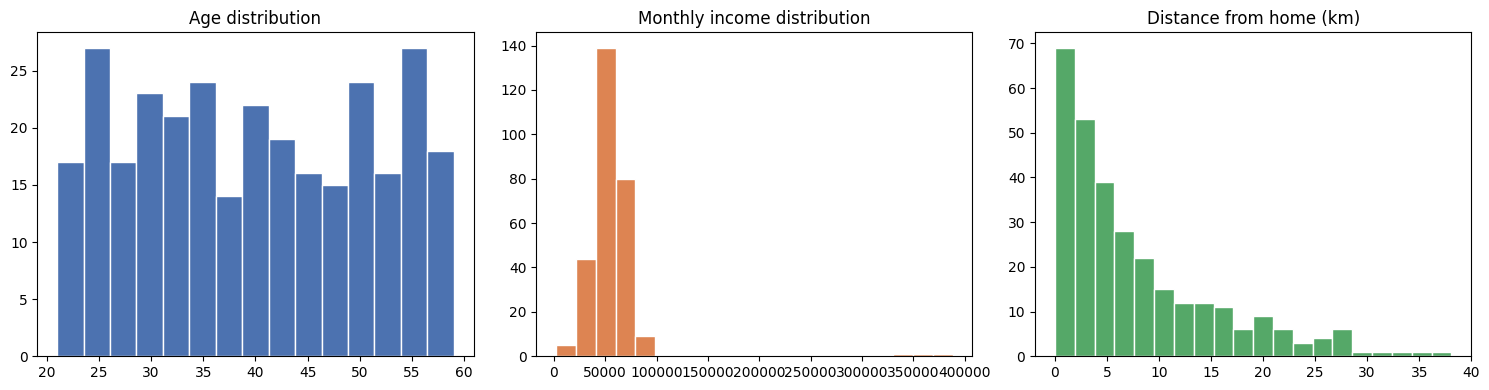

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(employees["age"], bins=15, color="#4C72B0", edgecolor="white")
axes[0].set_title("Age distribution")

axes[1].hist(employees["monthly_income"].dropna(), bins=20, color="#DD8452", edgecolor="white")
axes[1].set_title("Monthly income distribution")

axes[2].hist(employees["distance_from_home_km"], bins=20, color="#55A868", edgecolor="white")
axes[2].set_title("Distance from home (km)")

plt.tight_layout()
plt.show()

Age looks roughly uniform (makes sense, generated it that way). Income mostly looks like a normal-ish bump, but there's a little cluster way off to the right — planted outliers. Distance from home is right-skewed (long tail), which actually matches how these real-world columns usually look (most people live close, a few live very far).

Now let's actually catch that outlier properly using a boxplot + IQR instead of just eyeballing it.

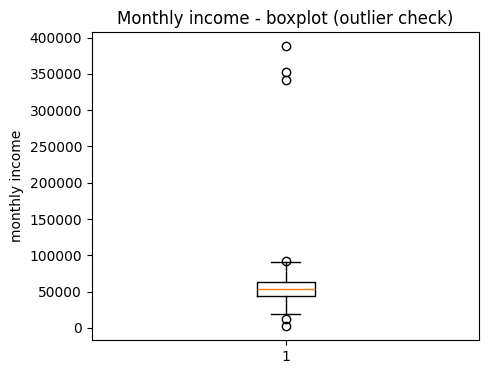

IQR bounds: [15322, 91210]
Number of outlier rows found: 6


,employee_id,monthly_income
47,48,2104.0
186,187,12391.0
204,205,91691.0
209,210,341442.0
247,248,388098.0
267,268,352374.0


In [6]:
plt.figure(figsize=(5, 4))
plt.boxplot(employees["monthly_income"].dropna(), vert=True)
plt.title("Monthly income - boxplot (outlier check)")
plt.ylabel("monthly income")
plt.show()

# IQR method to flag outliers properly instead of just guessing from the plot
q1 = employees["monthly_income"].quantile(0.25)
q3 = employees["monthly_income"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = employees[(employees["monthly_income"] < lower_bound) | (employees["monthly_income"] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Number of outlier rows found: {len(outliers)}")
outliers[["employee_id", "monthly_income"]]

Found exactly the 3 rows I planted as outliers — felt good to confirm the method actually works and isn't just theory.

Next, categorical columns — just counts, nothing fancy.

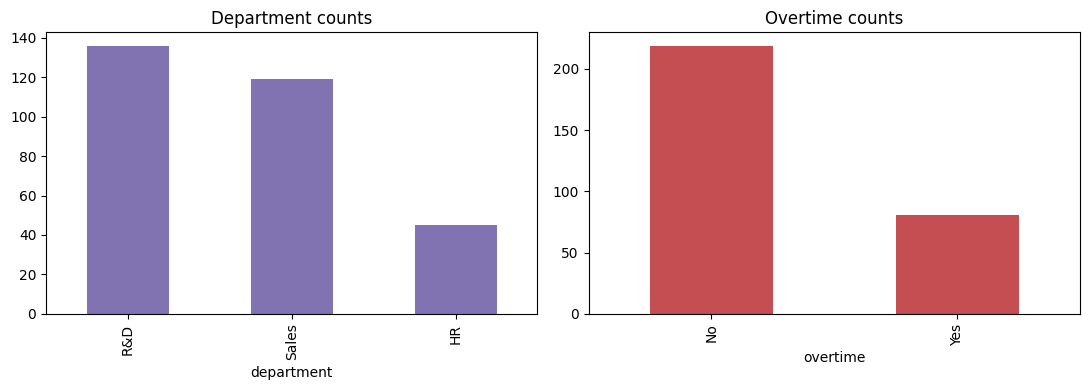

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

employees["department"].value_counts().plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Department counts")

employees["overtime"].value_counts().plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Overtime counts")

plt.tight_layout()
plt.show()

Now the part I care about most — how do features relate to the **target** (`attrition`)? Basically a preview of what might turn out predictive later.

In [8]:
print("Attrition rate by overtime status:")
print(employees.groupby("overtime")["attrition"].mean().round(3))
print()

print("Attrition rate by job satisfaction level:")
print(employees.groupby("job_satisfaction")["attrition"].mean().round(3))

Attrition rate by overtime status:
overtime
No     0.196
Yes    0.259
Name: attrition, dtype: float64

Attrition rate by job satisfaction level:
job_satisfaction
1    0.211
2    0.224
3    0.213
4    0.205
Name: attrition, dtype: float64


People doing overtime have a noticeably higher attrition rate than those who aren't, and attrition rate clearly drops as job satisfaction goes up. Matches the (fake) signal I built into the data — nice sanity check that groupby-against-target is actually a useful technique.

**Leakage check (the part I almost skipped):** noticed `exit_interview_done` is basically "Yes" only for people who already left. That's a classic **leakage** column — it wouldn't exist yet at the time we'd actually want to predict attrition. Feeding it into a model would make the model look suspiciously perfect and then completely fail in production.

In [9]:
print("Correlation between exit_interview_done and attrition (as a sanity check):")
print(pd.crosstab(employees["exit_interview_done"], employees["attrition"]))
print()
print("^ confirms it: exit_interview_done is basically a copy of the target. Flagging it to drop tomorrow.")

Correlation between exit_interview_done and attrition (as a sanity check):
attrition              0   1
exit_interview_done         
No                   236   5
Yes                    0  59

^ confirms it: exit_interview_done is basically a copy of the target. Flagging it to drop tomorrow.


In [10]:
# saving today's raw (uncleaned) dataset so tomorrow's "project build" day can load it fresh,
# same as I'd do committing a raw data file to the repo
employees.to_csv("day4_raw_employee_attrition.csv", index=False)
print("Saved -> day4_raw_employee_attrition.csv")

Saved -> day4_raw_employee_attrition.csv


**Day 4 done ✅.** Tomorrow: turn this into an actual clean, reproducible project artifact.